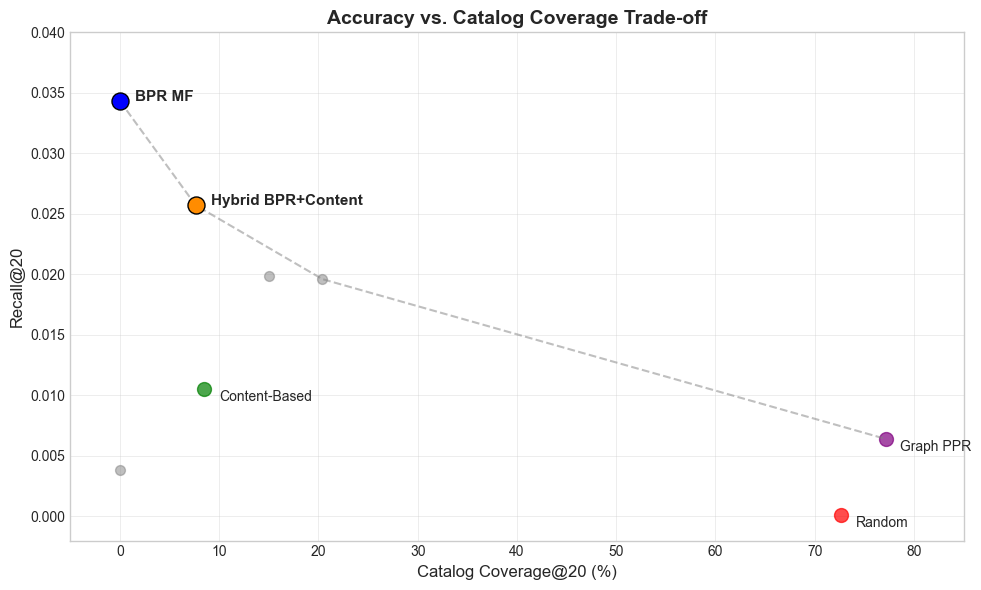

Plot gespeichert als 'pareto_tradeoff.pdf'


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Daten direkt aus deiner Phase 4 Log-Tabelle (Coverage in Prozent, Recall)
models = [
    "Popularity", "Trending", "Markov", "Graph PPR", "Random",
    "Content-Based", "Item-Item kNN", "BPR MF", "Hybrid BPR+Content"
]
recalls = [0.0343, 0.0038, 0.0196, 0.0064, 0.0001, 0.0105, 0.0199, 0.0343, 0.0257]
coverages = [0.02, 0.01, 20.41, 77.14, 72.66, 8.49, 15.02, 0.02, 7.64] # in %

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Scatter-Punkte zeichnen
colors = ['grey', 'grey', 'orange', 'purple', 'red', 'green', 'cyan', 'blue', 'darkorange']
for i in range(len(models)):
    # Hybrid und BPR besonders hervorheben
    if models[i] in ["Hybrid BPR+Content", "BPR MF"]:
        plt.scatter(coverages[i], recalls[i], s=150, c=colors[i], edgecolors='black', zorder=5)
        plt.annotate(models[i], (coverages[i] + 1.5, recalls[i]), fontweight='bold', fontsize=11)
    elif models[i] in ["Content-Based", "Graph PPR", "Random"]:
        plt.scatter(coverages[i], recalls[i], s=100, c=colors[i], alpha=0.7)
        plt.annotate(models[i], (coverages[i] + 1.5, recalls[i] - 0.001), fontsize=10)
    else:
        plt.scatter(coverages[i], recalls[i], s=50, c='grey', alpha=0.5)

plt.title('Accuracy vs. Catalog Coverage Trade-off', fontsize=14, fontweight='bold')
plt.xlabel('Catalog Coverage@20 (%)', fontsize=12)
plt.ylabel('Recall@20', fontsize=12)
plt.xlim(-5, 85)
plt.ylim(-0.002, 0.04)

# Pareto Frontier andeuten (gestrichelte Linie)
plt.plot([0.02, 7.64, 20.41, 77.14], [0.0343, 0.0257, 0.0196, 0.0064],
         linestyle='--', color='grey', alpha=0.5, label='Pareto Frontier')

plt.tight_layout()
plt.savefig('pareto_tradeoff.pdf', format='pdf')
plt.show()
print("Plot gespeichert als 'pareto_tradeoff.pdf'")

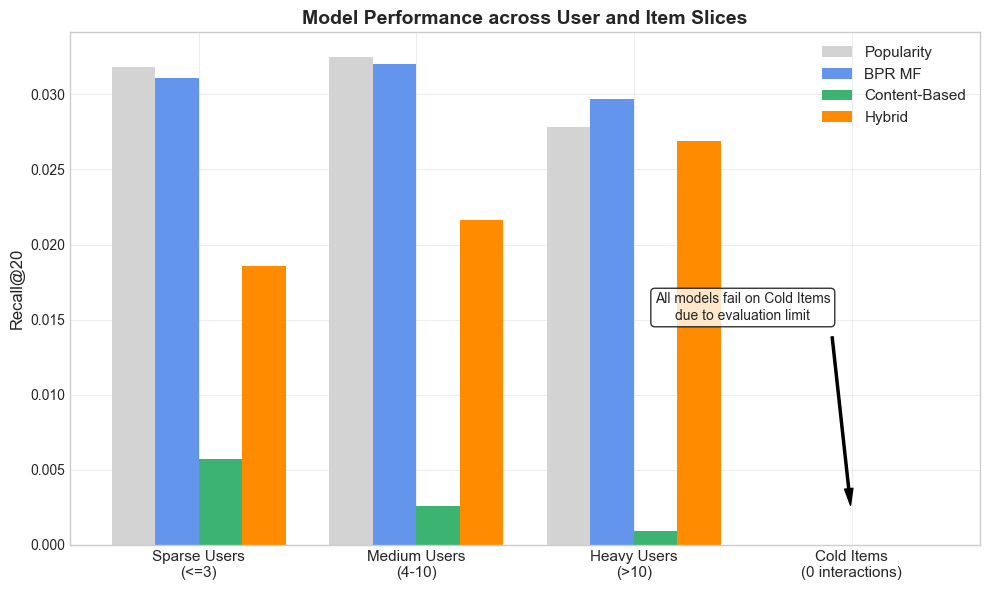

Plot gespeichert als 'slice_analysis.pdf'


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Daten aus Phase 7.1 und 7.2
categories = ['Sparse Users\n(<=3)', 'Medium Users\n(4-10)', 'Heavy Users\n(>10)', 'Cold Items\n(0 interactions)']

# Recall@20 Werte für unsere 4 Hauptdarsteller
pop_scores = [0.0318, 0.0325, 0.0278, 0.0000]
bpr_scores = [0.0311, 0.0320, 0.0297, 0.0000]
cb_scores =  [0.0057, 0.0026, 0.0009, 0.0000]
hybrid_scores=[0.0186, 0.0216, 0.0269, 0.0000]

x = np.arange(len(categories))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

rects1 = ax.bar(x - 1.5*width, pop_scores, width, label='Popularity', color='lightgrey')
rects2 = ax.bar(x - 0.5*width, bpr_scores, width, label='BPR MF', color='cornflowerblue')
rects3 = ax.bar(x + 0.5*width, cb_scores, width, label='Content-Based', color='mediumseagreen')
rects4 = ax.bar(x + 1.5*width, hybrid_scores, width, label='Hybrid', color='darkorange')

ax.set_ylabel('Recall@20', fontsize=12)
ax.set_title('Model Performance across User and Item Slices', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(fontsize=11)

# Annotiere den Cold-Start Fail für den Bericht
ax.annotate('All models fail on Cold Items\ndue to evaluation limit',
            xy=(3, 0.002), xytext=(2.5, 0.015),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
            fontsize=10, ha='center', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

plt.tight_layout()
plt.savefig('slice_analysis.pdf', format='pdf')
plt.show()
print("Plot gespeichert als 'slice_analysis.pdf'")